# 🔍 Detección de Fraude en Tarjetas de Crédito
## Modelos Predictivos con Machine Learning

---

## 📋 Contenido

1. [Introducción](#introduccion)
2. [Librerías y Configuración](#librerias)
3. [Carga de Datos](#carga)
4. [Exploración y Análisis (EDA)](#eda)
   - 4.1 [Vistazo General](#vistazo)
   - 4.2 [Datos Faltantes](#faltantes)
   - 4.3 [Desbalance de Clases](#desbalance)
   - 4.4 [Distribución Temporal](#temporal)
   - 4.5 [Análisis de Montos](#montos)
   - 4.6 [Correlaciones](#correlaciones)
   - 4.7 [Distribución de Features](#features)
5. [Preprocesamiento](#preprocesamiento)
   - 5.1 [Escalado de Features](#escalado)
   - 5.2 [División Train/Validation/Test](#split)
   - 5.3 [Manejo del Desbalance con SMOTE](#smote)
6. [Modelos Predictivos](#modelos)
   - 6.1 [Random Forest](#rf)
   - 6.2 [XGBoost](#xgb)
   - 6.3 [LightGBM (simple)](#lgb1)
   - 6.4 [LightGBM con Cross-Validation](#lgb2)
7. [Comparación de Modelos](#comparacion)
8. [Conclusiones](#conclusiones)

---
## 1. Introducción <a id='introduccion'></a>

Este notebook aborda la detección de transacciones fraudulentas en tarjetas de crédito.

El dataset contiene transacciones con las siguientes características:
- **V1 – V28**: Componentes principales obtenidos mediante PCA (los datos originales son confidenciales)
- **Time**: Segundos transcurridos desde la primera transacción del dataset
- **Amount**: Monto de la transacción
- **Class**: Variable objetivo — `1` = Fraude, `0` = Transacción legítima

⚠️ El dataset es **altamente desbalanceado**: los fraudes representan aproximadamente el 0.17% de las transacciones. Esto requiere técnicas especiales tanto en el modelado como en la evaluación.

---
## 2. Librerías y Configuración <a id='librerias'></a>

In [6]:
# === LIBRERÍAS PRINCIPALES ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# === PREPROCESAMIENTO ===
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# === MODELOS ===
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from lightgbm import LGBMClassifier

# === MÉTRICAS ===
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

import gc
from datetime import datetime

# === CONFIGURACIÓN GLOBAL ===
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE   = 42
VALID_SIZE     = 0.20
TEST_SIZE      = 0.20
NUMBER_KFOLDS  = 5

# LightGBM / XGBoost
MAX_ROUNDS   = 1000
EARLY_STOP   = 50
VERBOSE_EVAL = 100

# Random Forest
NUM_ESTIMATORS = 100

print('✅ Librerías cargadas correctamente')
print(f'   Fecha de ejecución: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ Librerías cargadas correctamente
   Fecha de ejecución: 2026-03-17 11:28:02


---
## 3. Carga de Datos <a id='carga'></a>

Ajusta la ruta `DATA_PATH` según la ubicación de tu archivo CSV.

In [7]:
# 👇 CAMBIA ESTA RUTA A LA UBICACIÓN DE TU ARCHIVO
DATA_PATH = "C:/Users/KAREN/OneDrive/Desktop/PAS/creditcard.csv"

data_df = pd.read_csv(DATA_PATH)

print(f'📦 Dataset cargado — Filas: {data_df.shape[0]:,}  |  Columnas: {data_df.shape[1]}')
print(f'   Memoria utilizada: {data_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

📦 Dataset cargado — Filas: 284,807  |  Columnas: 31
   Memoria utilizada: 67.4 MB


---
## 4. Exploración y Análisis (EDA) <a id='eda'></a>

### 4.1 Vistazo General <a id='vistazo'></a>

In [8]:
data_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
data_df.describe().T.style.bar(subset=['mean'], color='#5fba7d') \
       .background_gradient(subset=['std'], cmap='YlOrRd')

,count,mean,std,min,25%,50%,75%,max
Time,284807.000000,94813.859575,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.000000,0.000000,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.000000,0.000000,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.000000,-0.000000,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.000000,0.000000,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.000000,0.000000,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.000000,0.000000,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.000000,-0.000000,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.000000,0.000000,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.000000,-0.000000,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### 4.2 Datos Faltantes <a id='faltantes'></a>

In [10]:
missing = data_df.isnull().sum()
missing_pct = (missing / len(data_df) * 100).round(2)
missing_df = pd.DataFrame({'Total': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Total'] > 0]

if missing_df.empty:
    print('✅ No hay valores faltantes en el dataset.')
else:
    print('⚠️ Valores faltantes encontrados:')
    display(missing_df)

✅ No hay valores faltantes en el dataset.


### 4.3 Desbalance de Clases <a id='desbalance'></a>

Distribución de clases:
  Legítimas (0):  284,315  (99.827%)
  Fraudes   (1):      492  (0.173%)
  Ratio desbalance: 1 fraude por cada 577 transacciones legítimas


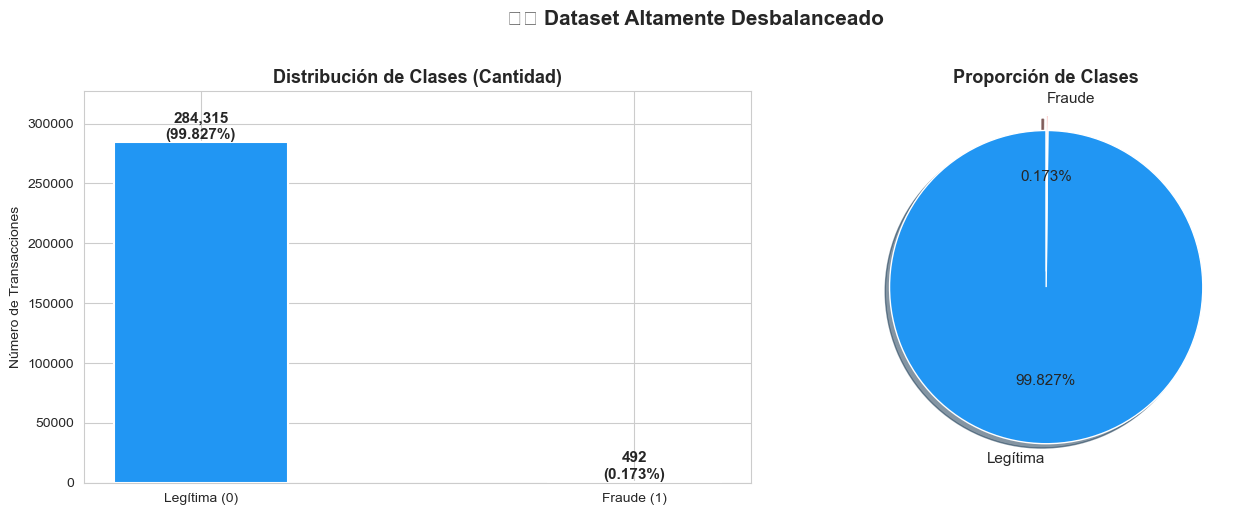

In [11]:
class_counts = data_df['Class'].value_counts()
class_pct    = data_df['Class'].value_counts(normalize=True) * 100

print('Distribución de clases:')
print(f'  Legítimas (0): {class_counts[0]:>8,}  ({class_pct[0]:.3f}%)')
print(f'  Fraudes   (1): {class_counts[1]:>8,}  ({class_pct[1]:.3f}%)')
print(f'  Ratio desbalance: 1 fraude por cada {int(class_counts[0]/class_counts[1])} transacciones legítimas')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colors = ['#2196F3', '#F44336']
bars = axes[0].bar(['Legítima (0)', 'Fraude (1)'], class_counts.values, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}\n({pct:.3f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de Clases (Cantidad)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Transacciones')
axes[0].set_ylim(0, class_counts.max() * 1.15)

# Pie chart en escala log para visualizar el desbalance
axes[1].pie(class_counts.values, labels=['Legítima', 'Fraude'],
            colors=colors, autopct='%1.3f%%', startangle=90,
            explode=(0, 0.1), shadow=True, textprops={'fontsize': 11})
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.suptitle('⚠️ Dataset Altamente Desbalanceado', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Distribución Temporal <a id='temporal'></a>

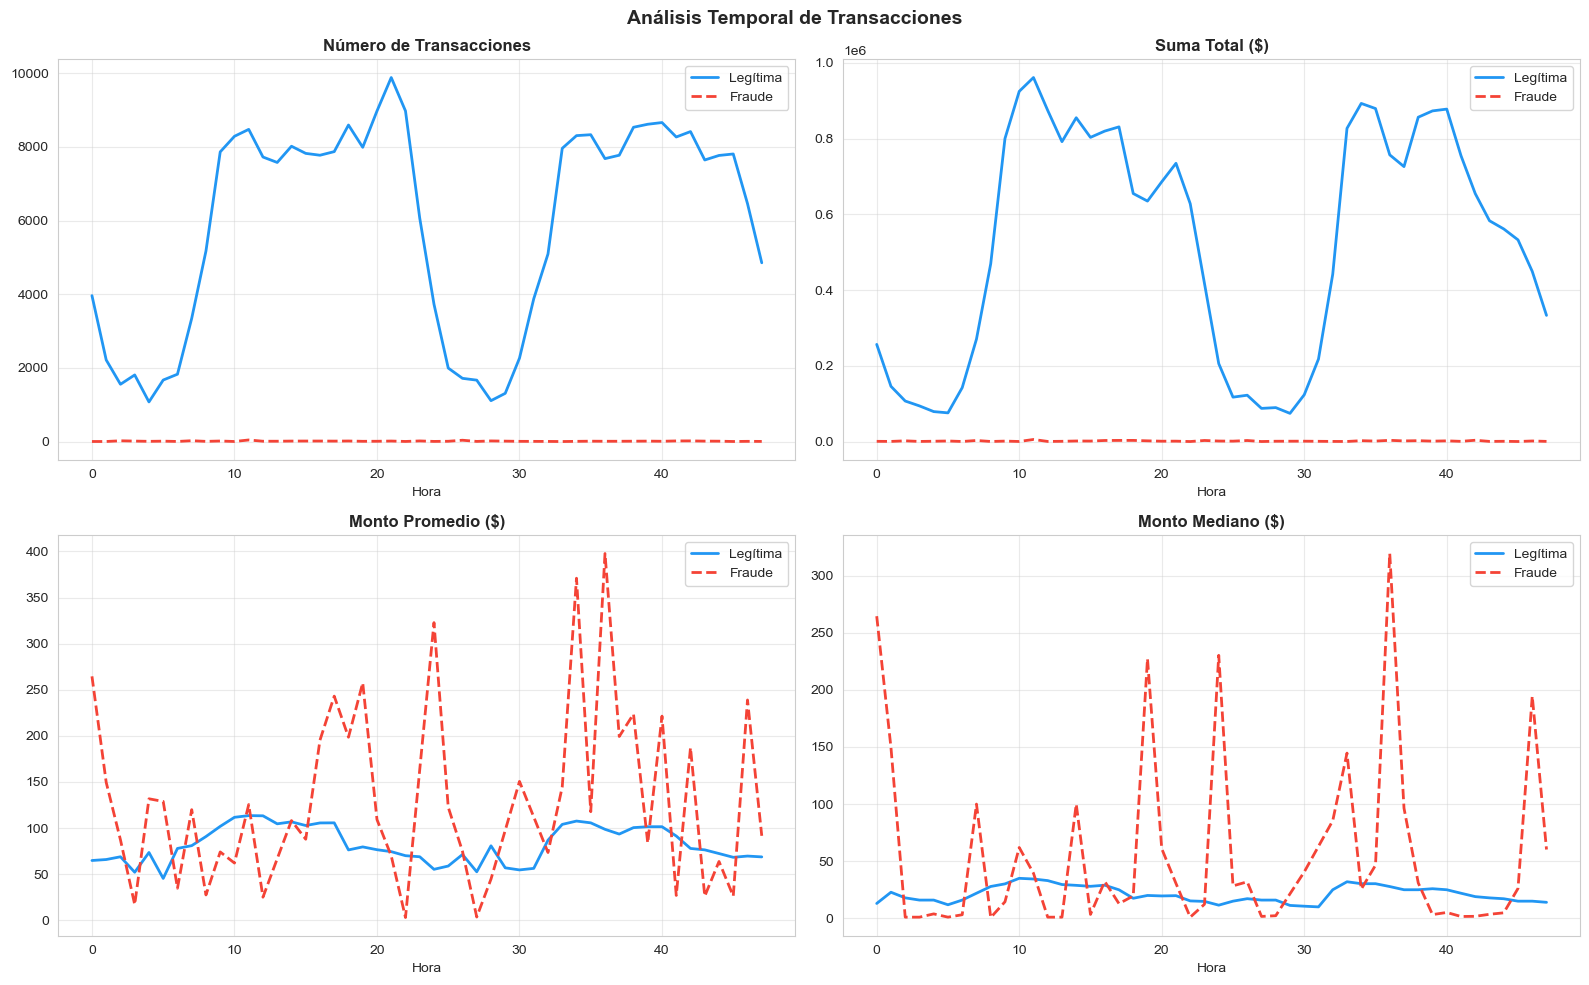

In [12]:
data_df['Hour'] = (data_df['Time'] / 3600).apply(np.floor).astype(int)

hourly = data_df.groupby(['Hour', 'Class'])['Amount'].agg(
    Transacciones='count', Suma='sum', Media='mean', Mediana='median'
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = [('Transacciones', 'Número de Transacciones'), 
           ('Suma', 'Suma Total ($)'),
           ('Media', 'Monto Promedio ($)'), 
           ('Mediana', 'Monto Mediano ($)')]

for ax, (col, title) in zip(axes.flatten(), metrics):
    leg = hourly[hourly['Class'] == 0]
    frau = hourly[hourly['Class'] == 1]
    ax.plot(leg['Hour'], leg[col], label='Legítima', color='#2196F3', linewidth=2)
    ax.plot(frau['Hour'], frau[col], label='Fraude', color='#F44336', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Hora')
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.suptitle('Análisis Temporal de Transacciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Análisis de Montos <a id='montos'></a>

Estadísticas de Monto por Clase:


,Legítima,Fraude
count,284315.00,492.00
mean,88.29,122.21
std,250.11,256.68
min,0.00,0.00
25%,5.65,1.00
50%,22.00,9.25
75%,77.05,105.89
max,25691.16,2125.87


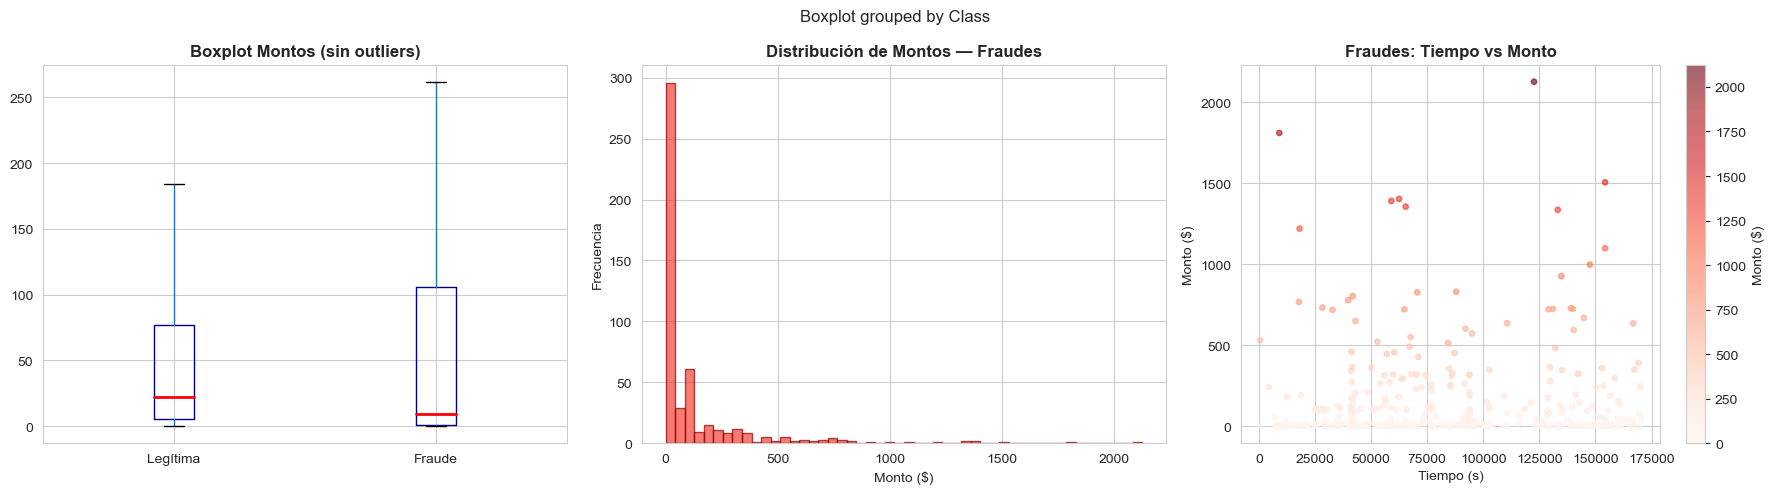

In [13]:
legit = data_df[data_df['Class'] == 0]['Amount']
fraud = data_df[data_df['Class'] == 1]['Amount']

print('Estadísticas de Monto por Clase:')
stats = pd.DataFrame({'Legítima': legit.describe(), 'Fraude': fraud.describe()})
display(stats.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot sin outliers
data_df.boxplot(column='Amount', by='Class', ax=axes[0], showfliers=False,
                boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Boxplot Montos (sin outliers)', fontweight='bold')
axes[0].set_xticklabels(['Legítima', 'Fraude'])
axes[0].set_xlabel('')

# Histograma de fraudes
axes[1].hist(fraud, bins=50, color='#F44336', edgecolor='darkred', alpha=0.7)
axes[1].set_title('Distribución de Montos — Fraudes', fontweight='bold')
axes[1].set_xlabel('Monto ($)')
axes[1].set_ylabel('Frecuencia')

# Scatter: tiempo vs monto (fraudes)
fraud_df = data_df[data_df['Class'] == 1]
sc = axes[2].scatter(fraud_df['Time'], fraud_df['Amount'], 
                     c=fraud_df['Amount'], cmap='Reds', alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[2], label='Monto ($)')
axes[2].set_title('Fraudes: Tiempo vs Monto', fontweight='bold')
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_ylabel('Monto ($)')

plt.tight_layout()
plt.show()

### 4.6 Correlaciones <a id='correlaciones'></a>

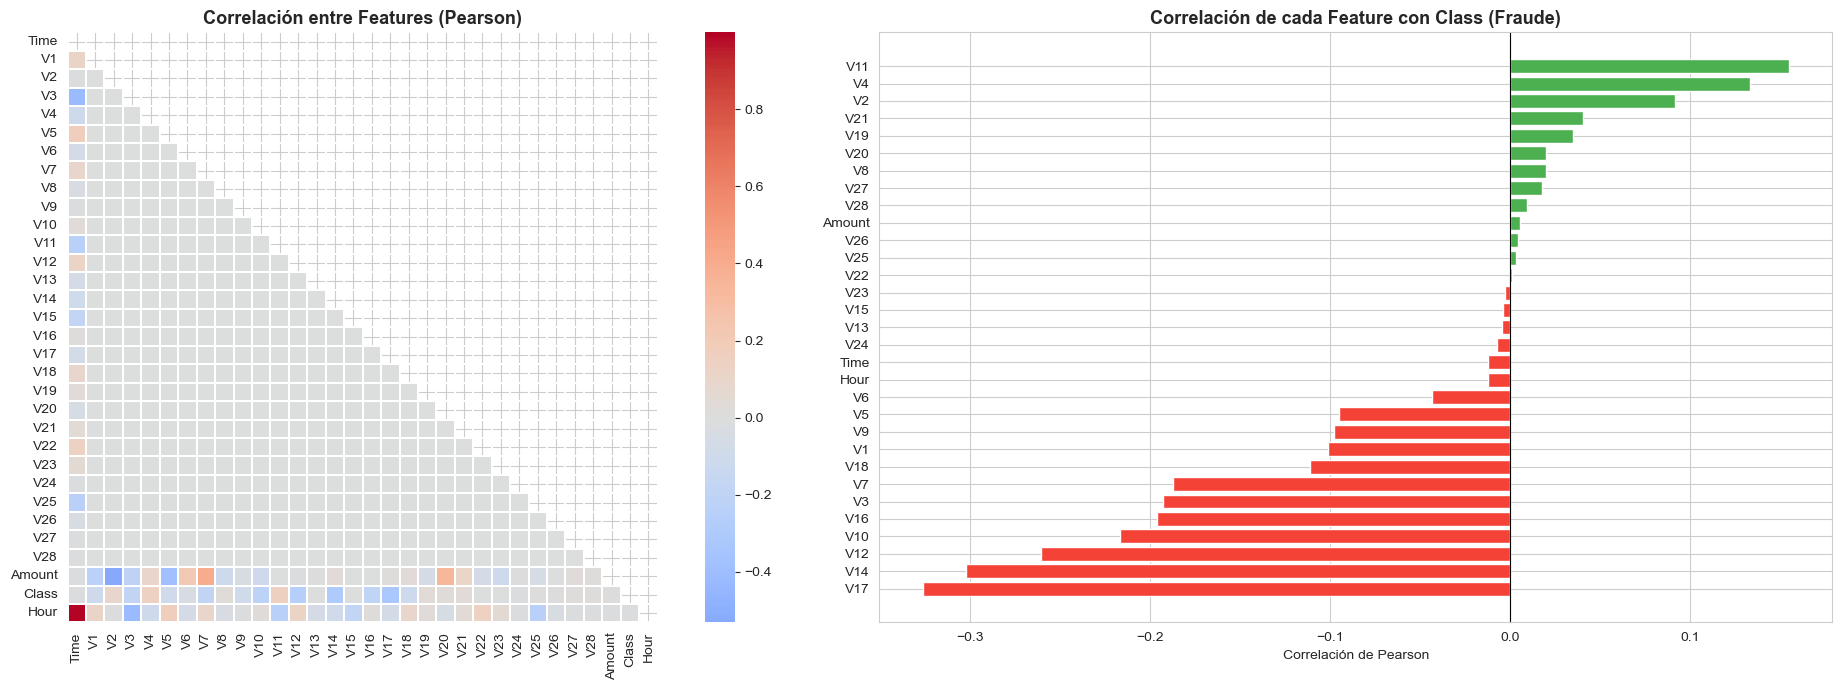


Top 10 features más correlacionadas con fraude:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Mapa de correlación completo
corr = data_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Solo triángulo inferior
sns.heatmap(corr, mask=mask, ax=axes[0], cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, square=True, fmt='.2f')
axes[0].set_title('Correlación entre Features (Pearson)', fontsize=13, fontweight='bold')

# Correlación de cada feature con la clase
corr_class = data_df.corr()['Class'].drop('Class').sort_values()
colors_corr = ['#F44336' if x < 0 else '#4CAF50' for x in corr_class]
axes[1].barh(corr_class.index, corr_class.values, color=colors_corr, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación de cada Feature con Class (Fraude)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.show()

# Top correlaciones
print('\nTop 10 features más correlacionadas con fraude:')
print(corr_class.abs().sort_values(ascending=False).head(10).to_string())

### 4.7 Distribución de Features por Clase <a id='features'></a>

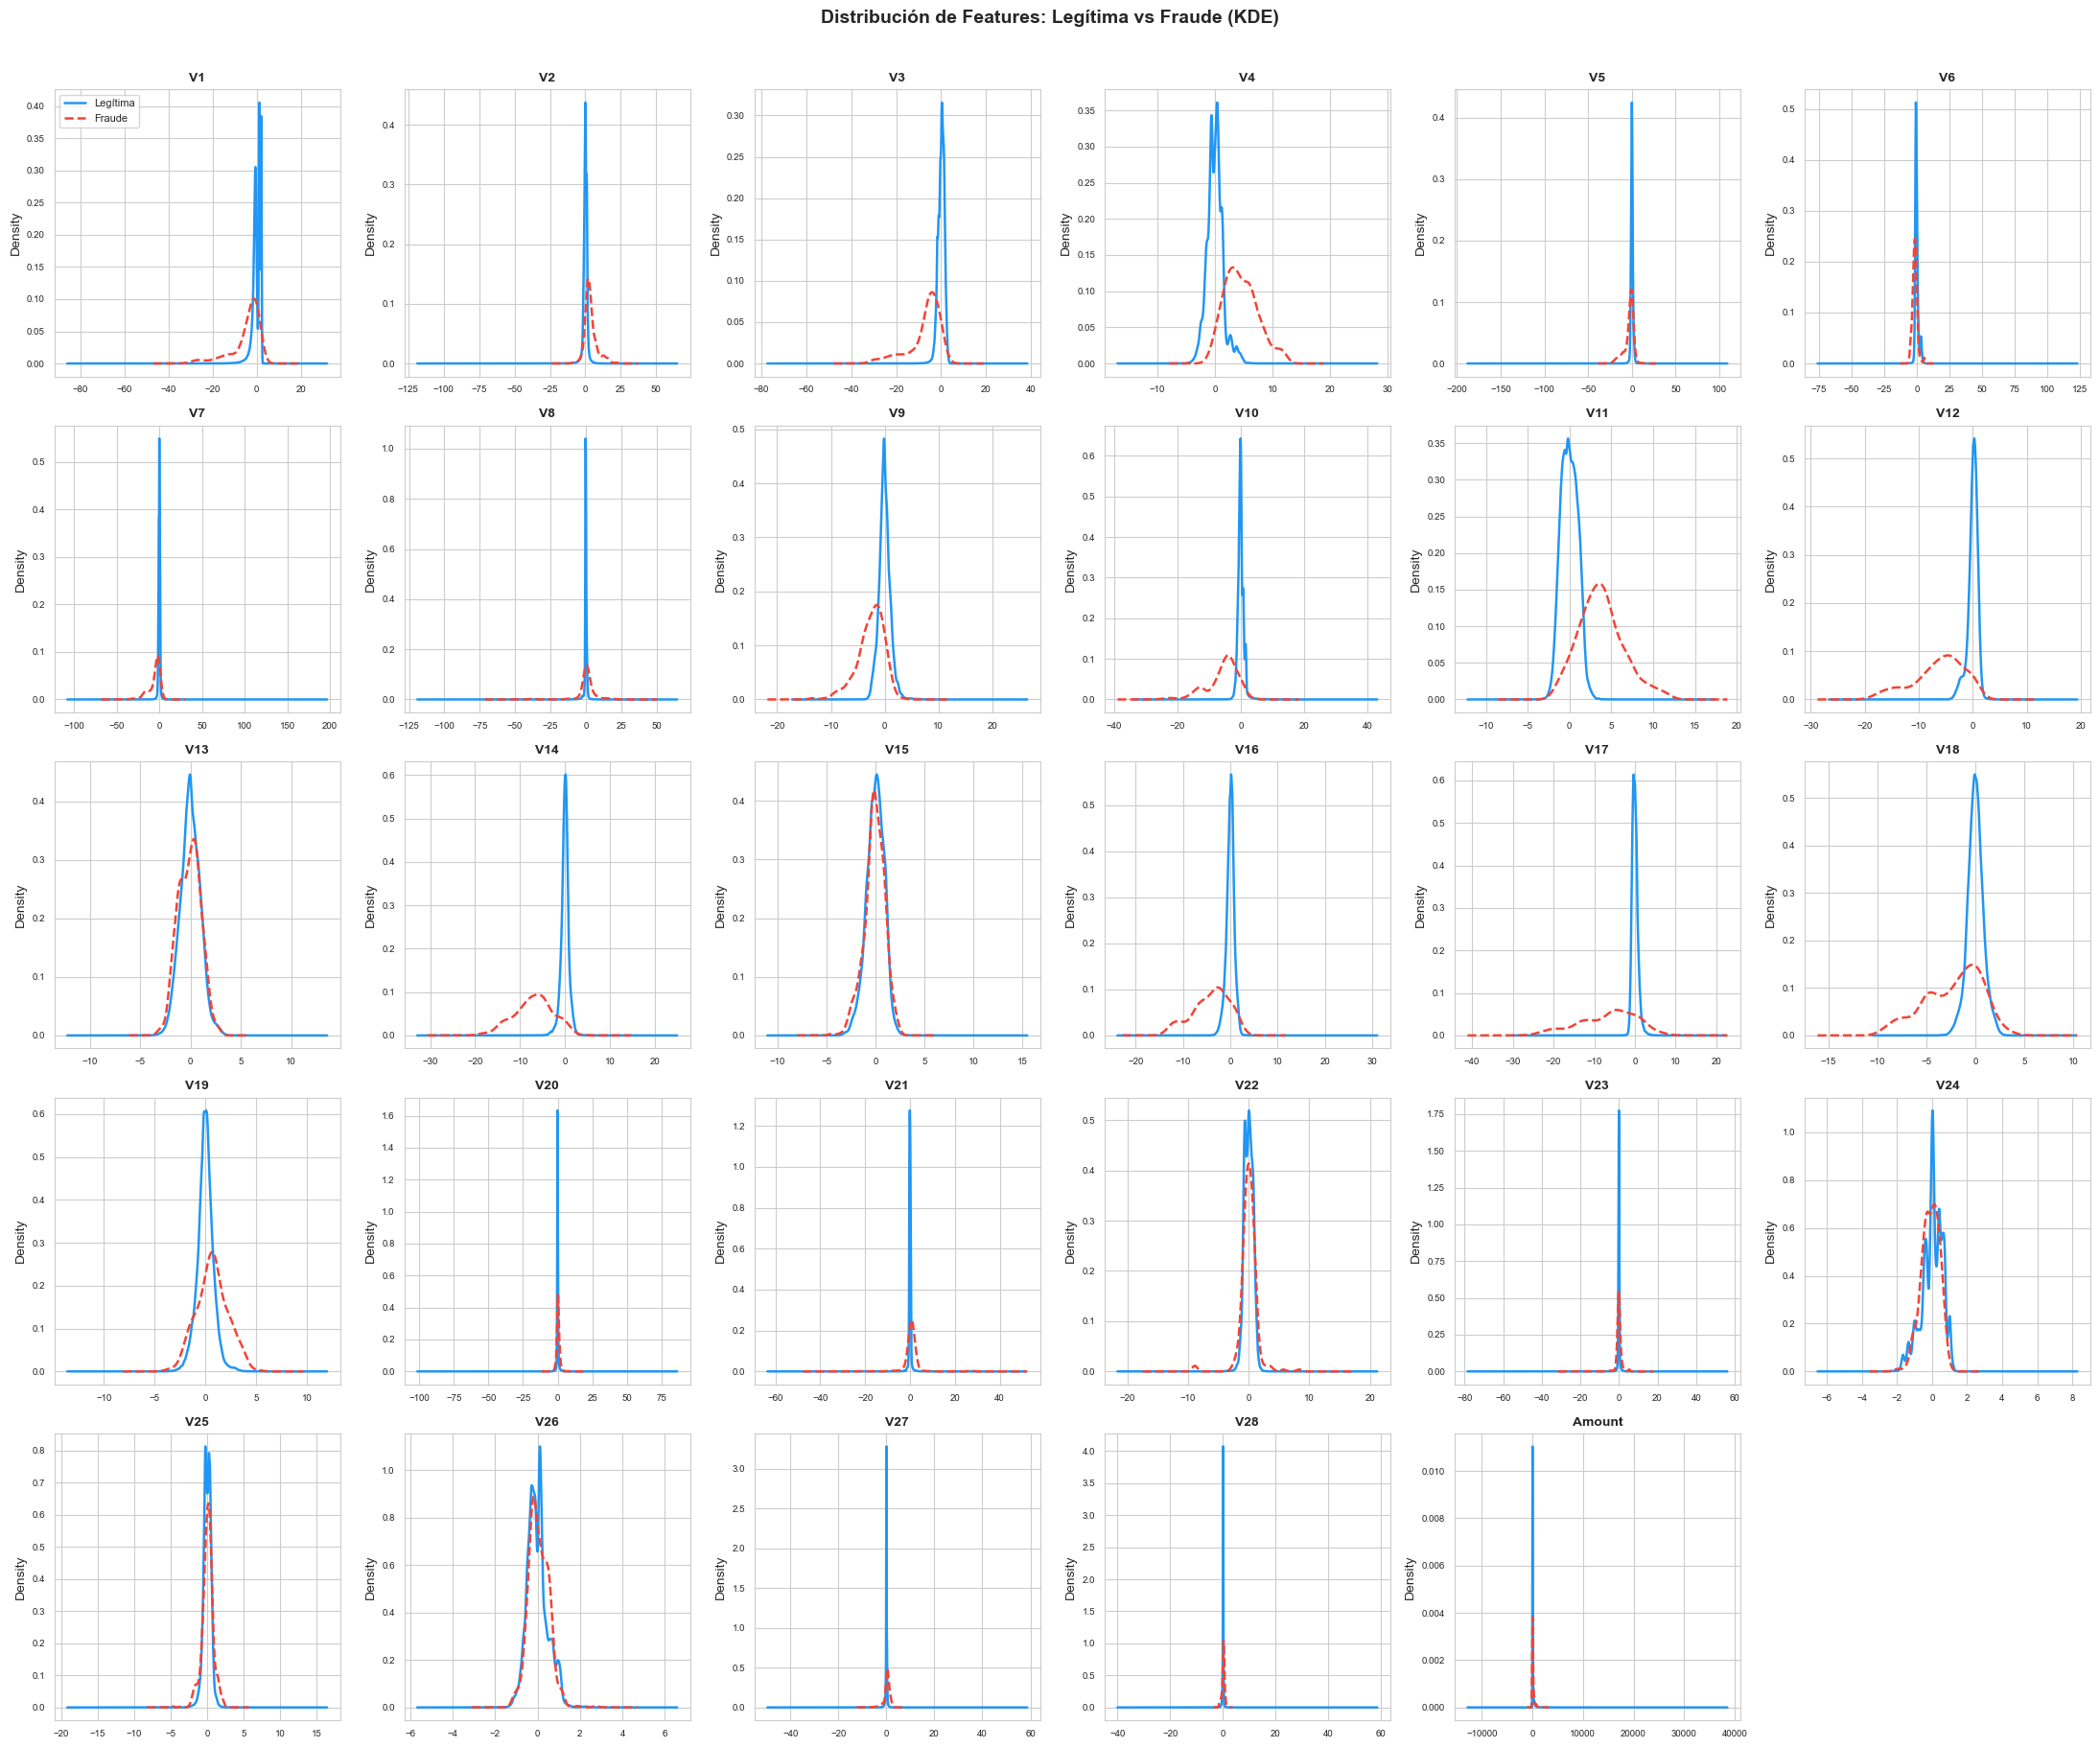

In [15]:
features_v = [f'V{i}' for i in range(1, 29)] + ['Amount']
t0 = data_df[data_df['Class'] == 0]
t1 = data_df[data_df['Class'] == 1]

fig, axes = plt.subplots(5, 6, figsize=(22, 18))
axes = axes.flatten()

for i, feat in enumerate(features_v):
    ax = axes[i]
    t0[feat].plot.kde(ax=ax, label='Legítima', color='#2196F3', linewidth=1.8)
    t1[feat].plot.kde(ax=ax, label='Fraude',   color='#F44336', linewidth=1.8, linestyle='--')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=8)

# Ocultar ejes vacíos
for j in range(len(features_v), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Features: Legítima vs Fraude (KDE)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Preprocesamiento <a id='preprocesamiento'></a>

### 5.1 Escalado de Features <a id='escalado'></a>

Las features V1-V28 ya están normalizadas por PCA. Escalamos `Time` y `Amount` con `RobustScaler` (más robusto ante outliers).

In [16]:
df = data_df.copy()

# RobustScaler: usa mediana y IQR → resistente a outliers
scaler = RobustScaler()
df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])

print('✅ Time y Amount escalados con RobustScaler')
df[['Time', 'Amount']].describe().round(3)

✅ Time y Amount escalados con RobustScaler


,Time,Amount
count,284807.000,284807.000
mean,0.119,0.927
std,0.558,3.495
min,-0.995,-0.307
25%,-0.358,-0.229
50%,0.000,0.000
75%,0.642,0.771
max,1.035,358.683


### 5.2 División Train / Validation / Test <a id='split'></a>

In [17]:
TARGET     = 'Class'
PREDICTORS = [c for c in df.columns if c != TARGET]

X = df[PREDICTORS]
y = df[TARGET]

# Primer split: separar test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Segundo split: separar train y validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val, test_size=VALID_SIZE, random_state=RANDOM_STATE, stratify=y_train_val
)

print(f'División estratificada del dataset:')
print(f'  Train      : {X_train.shape[0]:>8,} filas  ({X_train.shape[0]/len(df)*100:.1f}%)  | Fraudes: {y_train.sum()}')
print(f'  Validation : {X_valid.shape[0]:>8,} filas  ({X_valid.shape[0]/len(df)*100:.1f}%)  | Fraudes: {y_valid.sum()}')
print(f'  Test       : {X_test.shape[0]:>8,} filas  ({X_test.shape[0]/len(df)*100:.1f}%)  | Fraudes: {y_test.sum()}')

División estratificada del dataset:
  Train      :  182,276 filas  (64.0%)  | Fraudes: 315
  Validation :   45,569 filas  (16.0%)  | Fraudes: 79
  Test       :   56,962 filas  (20.0%)  | Fraudes: 98


### 5.3 Manejo del Desbalance con SMOTE <a id='smote'></a>

SMOTE (Synthetic Minority Oversampling TEchnique) genera ejemplos sintéticos de la clase minoritaria. **Solo se aplica al set de entrenamiento.**

Distribución ANTES de SMOTE: {0: 181961, 1: 315}
Distribución DESPUÉS de SMOTE: {0: 181961, 1: 90980}


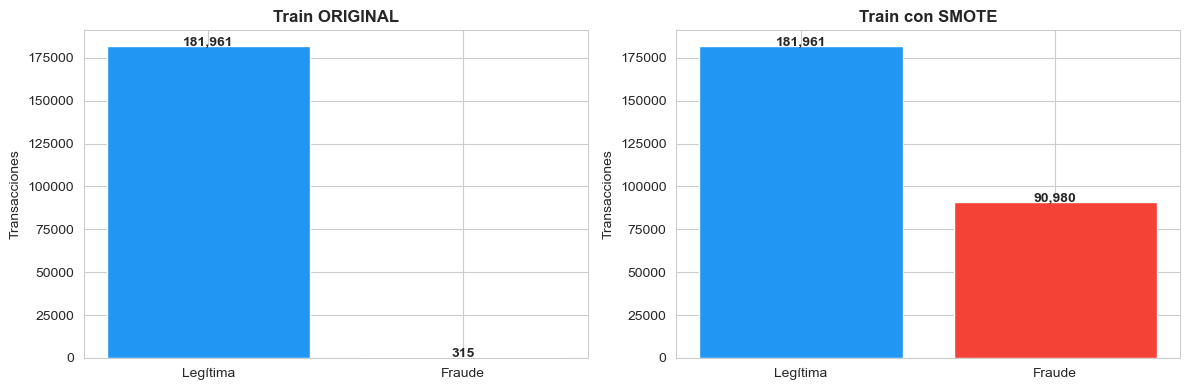

In [18]:
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.5)  # lleva fraudes al 33% del total
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Distribución ANTES de SMOTE: {y_train.value_counts().to_dict()}')
print(f'Distribución DESPUÉS de SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (counts, title) in zip(axes, [
    (y_train.value_counts(), 'Train ORIGINAL'),
    (pd.Series(y_train_sm).value_counts(), 'Train con SMOTE')
]):
    ax.bar(['Legítima', 'Fraude'], counts.sort_index().values, color=['#2196F3', '#F44336'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Transacciones')
    for i, v in enumerate(counts.sort_index().values):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Modelos Predictivos <a id='modelos'></a>

Función auxiliar para evaluar y visualizar resultados de forma consistente.

In [21]:
# Diccionario para guardar resultados de todos los modelos
results = {}

def evaluate_model(name, y_true, y_pred, y_prob, show_plots=True):
    """Calcula métricas y genera visualizaciones para un modelo."""
    auc   = roc_auc_score(y_true, y_prob)
    ap    = average_precision_score(y_true, y_prob)
    f1    = f1_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred)
    rec   = recall_score(y_true, y_pred)
    
    results[name] = {'AUC-ROC': auc, 'Avg Precision': ap, 'F1': f1,
                     'Precision': prec, 'Recall': rec}
    
    print(f'  Modelo: {name}')
    print(f'  ROC-AUC          : {auc:.4f}')
    print(f'  Avg Precision    : {ap:.4f}')
    print(f'  F1-Score         : {f1:.4f}')
    print(f'  Precision        : {prec:.4f}')
    print(f'  Recall           : {rec:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Legítima', 'Fraude']))
    
    if show_plots:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Matriz de confusión
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['Legítima', 'Fraude'],
                    yticklabels=['Legítima', 'Fraude'],
                    linewidths=1, linecolor='white')
        axes[0].set_title(f'Matriz de Confusión — {name}', fontweight='bold')
        axes[0].set_ylabel('Real')
        axes[0].set_xlabel('Predicho')
        
        # Curva ROC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
        axes[1].plot([0,1], [0,1], 'k--', lw=1)
        axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
        axes[1].set_title(f'Curva ROC — {name}', fontweight='bold')
        axes[1].set_xlabel('Tasa de Falsos Positivos')
        axes[1].set_ylabel('Tasa de Verdaderos Positivos')
        axes[1].legend(loc='lower right')
        
        # Curva Precision-Recall (más informativa con datos desbalanceados)
        prec_c, rec_c, _ = precision_recall_curve(y_true, y_prob)
        axes[2].plot(rec_c, prec_c, color='green', lw=2, label=f'AP = {ap:.4f}')
        axes[2].fill_between(rec_c, prec_c, alpha=0.1, color='green')
        axes[2].set_title(f'Curva Precision-Recall — {name}', fontweight='bold')
        axes[2].set_xlabel('Recall')
        axes[2].set_ylabel('Precision')
        axes[2].legend(loc='upper right')
        
        plt.suptitle(f'Evaluación: {name}', fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    
    return results[name]


def plot_feature_importance(model, feature_names, model_name, top_n=20, color='steelblue'):
    """Grafica la importancia de features de un modelo."""
    importances = pd.DataFrame({
        'Feature': feature_names,
        'Importancia': model.feature_importances_
    }).sort_values('Importancia', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importancia', y='Feature', data=importances, color=color)
    plt.title(f'Top {top_n} Features — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('✅ Funciones auxiliares definidas')

✅ Funciones auxiliares definidas


### 6.1 Random Forest <a id='rf'></a>

🌲 Entrenando Random Forest...
⏱ Tiempo de entrenamiento: 22s
  Modelo: Random Forest
  ROC-AUC          : 0.9747
  Avg Precision    : 0.7737
  F1-Score         : 0.7006
  Precision        : 0.6327
  Recall           : 0.7848

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     45490
      Fraude       0.63      0.78      0.70        79

    accuracy                           1.00     45569
   macro avg       0.82      0.89      0.85     45569
weighted avg       1.00      1.00      1.00     45569



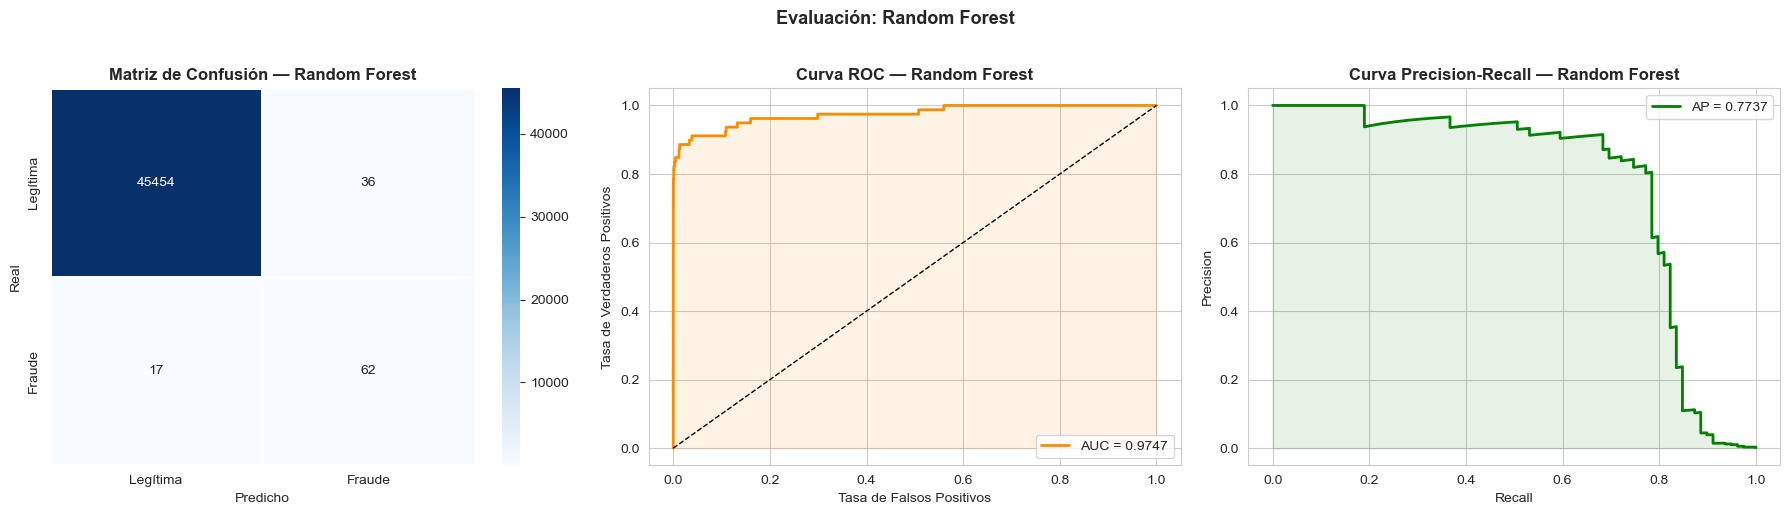

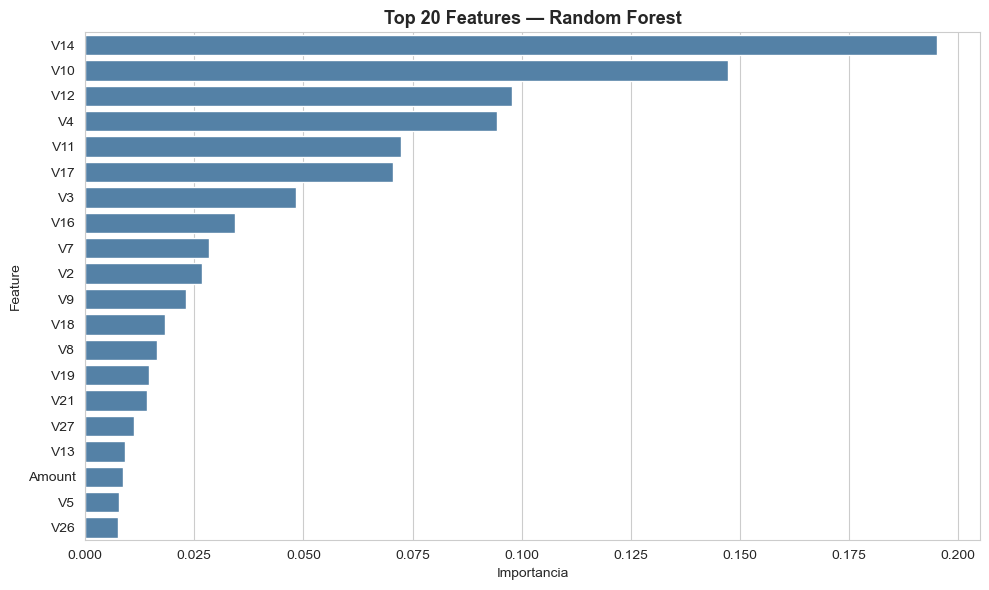

In [22]:
print('🌲 Entrenando Random Forest...')
t0 = datetime.now()

rf = RandomForestClassifier(
    n_estimators=NUM_ESTIMATORS,
    criterion='gini',
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced',    # manejo del desbalance
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train_sm, y_train_sm)

print(f'⏱ Tiempo de entrenamiento: {(datetime.now()-t0).seconds}s')

rf_preds = rf.predict(X_valid)
rf_probs = rf.predict_proba(X_valid)[:, 1]

evaluate_model('Random Forest', y_valid, rf_preds, rf_probs)
plot_feature_importance(rf, PREDICTORS, 'Random Forest', color='steelblue')

### 6.2 XGBoost <a id='xgb'></a>

🚀 Entrenando XGBoost...
[0]	train-auc:0.99432	valid-auc:0.97483
[96]	train-auc:0.99967	valid-auc:0.97103
⏱ Tiempo de entrenamiento: 6s
✅ Mejor ronda: 46
  Modelo: XGBoost
  ROC-AUC          : 0.9710
  Avg Precision    : 0.6997
  F1-Score         : 0.2529
  Precision        : 0.1494
  Recall           : 0.8228

              precision    recall  f1-score   support

    Legítima       1.00      0.99      1.00     45490
      Fraude       0.15      0.82      0.25        79

    accuracy                           0.99     45569
   macro avg       0.57      0.91      0.62     45569
weighted avg       1.00      0.99      0.99     45569



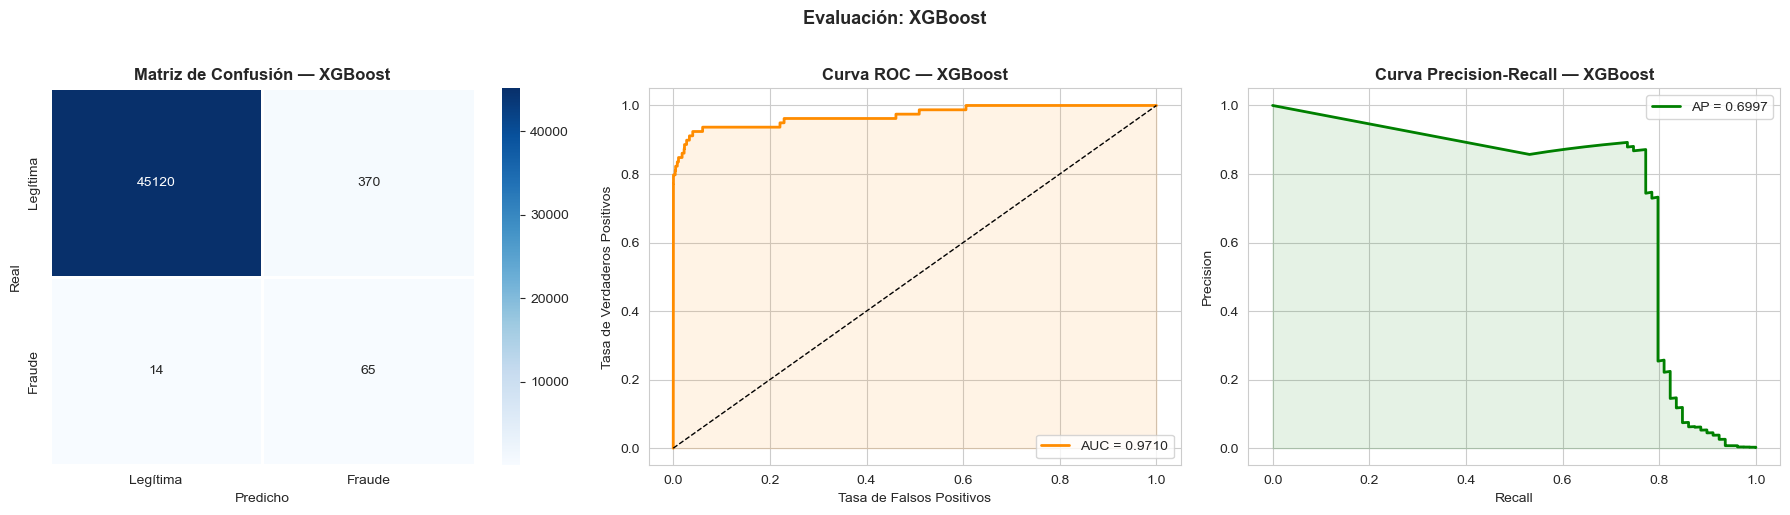

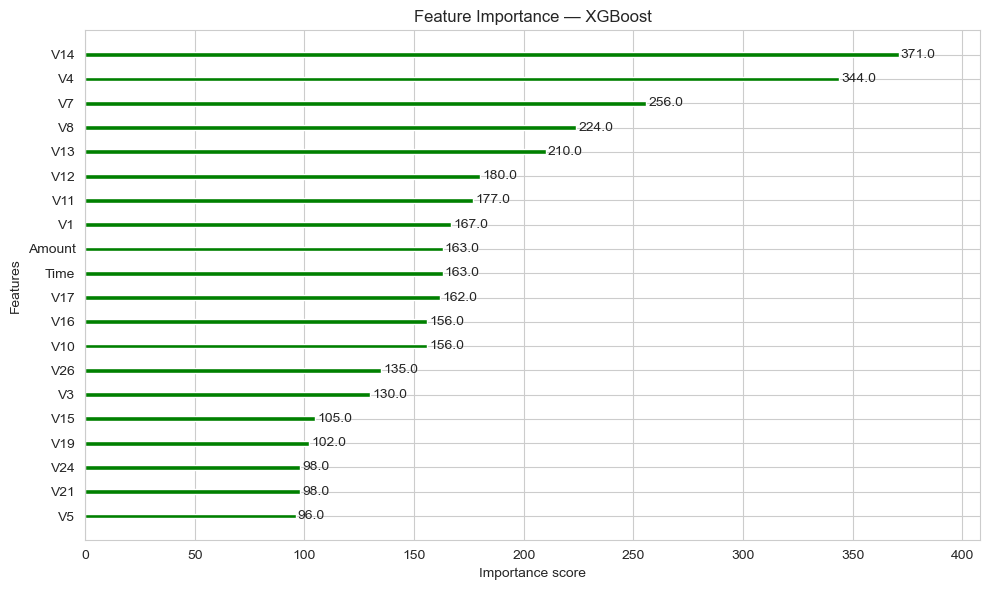

In [24]:
print('🚀 Entrenando XGBoost...')

scale_pos = int(y_train_sm.value_counts()[0] / y_train_sm.value_counts()[1])

dtrain = xgb.DMatrix(X_train_sm, label=y_train_sm)
dvalid = xgb.DMatrix(X_valid,    label=y_valid)
dtest  = xgb.DMatrix(X_test,     label=y_test)

xgb_params = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'eta':              0.039,
    'max_depth':        6,
    'subsample':        0.8,
    'colsample_bytree': 0.9,
    'min_child_weight': 5,
    'scale_pos_weight': scale_pos,
    'seed':             RANDOM_STATE,
    'verbosity':        0
}

t0 = datetime.now()
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=MAX_ROUNDS,
    evals=[(dtrain, 'train'), (dvalid, 'valid')],
    early_stopping_rounds=EARLY_STOP,
    maximize=True,
    verbose_eval=VERBOSE_EVAL
)
print(f'⏱ Tiempo de entrenamiento: {(datetime.now()-t0).seconds}s')
print(f'✅ Mejor ronda: {xgb_model.best_iteration}')

xgb_probs = xgb_model.predict(dvalid)
xgb_preds = (xgb_probs > 0.5).astype(int)

evaluate_model('XGBoost', y_valid, xgb_preds, xgb_probs)

fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(xgb_model, ax=ax, color='green', max_num_features=20,
                    title='Feature Importance — XGBoost')
plt.tight_layout()
plt.show()

### 6.3 LightGBM Simple <a id='lgb1'></a>

💡 Entrenando LightGBM...
[100]	train's auc: 0.999884	valid's auc: 0.978631
⏱ Tiempo de entrenamiento: 3s
✅ Mejor ronda: 81
  Modelo: LightGBM
  ROC-AUC          : 0.9803
  Avg Precision    : 0.7278
  F1-Score         : 0.4337
  Precision        : 0.2913
  Recall           : 0.8481

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     45490
      Fraude       0.29      0.85      0.43        79

    accuracy                           1.00     45569
   macro avg       0.65      0.92      0.72     45569
weighted avg       1.00      1.00      1.00     45569



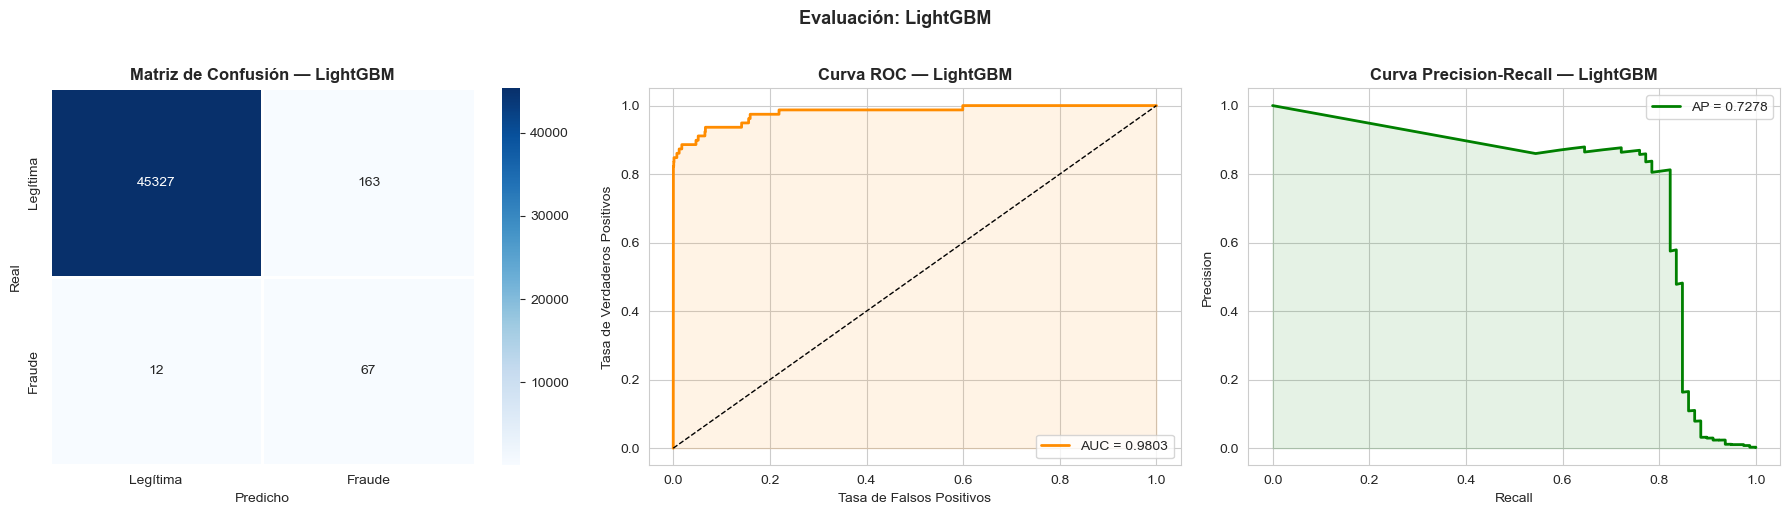

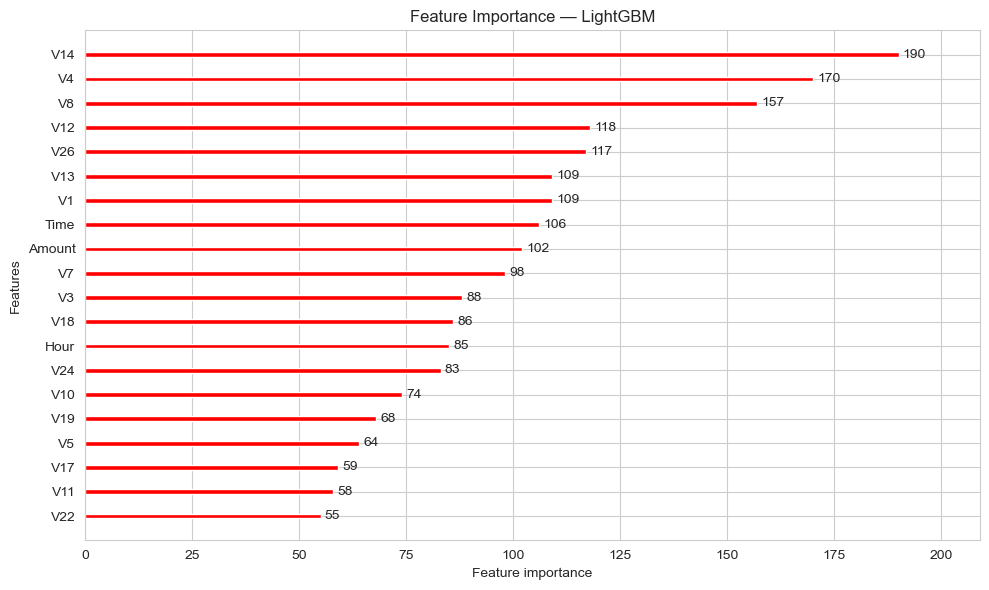

In [25]:
print('💡 Entrenando LightGBM...')

lgb_params = {
    'boosting_type':     'gbdt',
    'objective':         'binary',
    'metric':            'auc',
    'learning_rate':     0.05,
    'num_leaves':        31,
    'max_depth':         -1,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'scale_pos_weight':  scale_pos,
    'n_jobs':            -1,
    'seed':              RANDOM_STATE,
    'verbose':           -1
}

lgb_train = lgb.Dataset(X_train_sm, label=y_train_sm)
lgb_valid = lgb.Dataset(X_valid,    label=y_valid,    reference=lgb_train)

t0 = datetime.now()
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=MAX_ROUNDS,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=EARLY_STOP, verbose=False),
        lgb.log_evaluation(period=VERBOSE_EVAL)
    ]
)
print(f'⏱ Tiempo de entrenamiento: {(datetime.now()-t0).seconds}s')
print(f'✅ Mejor ronda: {lgb_model.best_iteration}')

lgb_probs = lgb_model.predict(X_valid)
lgb_preds = (lgb_probs > 0.5).astype(int)

evaluate_model('LightGBM', y_valid, lgb_preds, lgb_probs)

fig, ax = plt.subplots(figsize=(10, 6))
lgb.plot_importance(lgb_model, ax=ax, color='red', max_num_features=20,
                    title='Feature Importance — LightGBM')
plt.tight_layout()
plt.show()

### 6.4 LightGBM con Cross-Validation (K-Fold) <a id='lgb2'></a>

Validación cruzada estratificada para obtener estimaciones más robustas del rendimiento.

🔄 LightGBM con 5-Fold Stratified Cross-Validation...
  Fold 1/5 — AUC: 0.94152  (mejor ronda: 1)
  Fold 2/5 — AUC: 0.91674  (mejor ronda: 218)
  Fold 3/5 — AUC: 0.95780  (mejor ronda: 8)
  Fold 4/5 — AUC: 0.86844  (mejor ronda: 1)
  Fold 5/5 — AUC: 0.90504  (mejor ronda: 1)

  AUC promedio CV : 0.91791  ±  0.03087
  Modelo: LightGBM CV
  ROC-AUC          : 0.9461
  Avg Precision    : 0.7034
  F1-Score         : 0.2404
  Precision        : 0.1388
  Recall           : 0.8980

              precision    recall  f1-score   support

    Legítima       1.00      0.99      1.00     56864
      Fraude       0.14      0.90      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.62     56962
weighted avg       1.00      0.99      0.99     56962



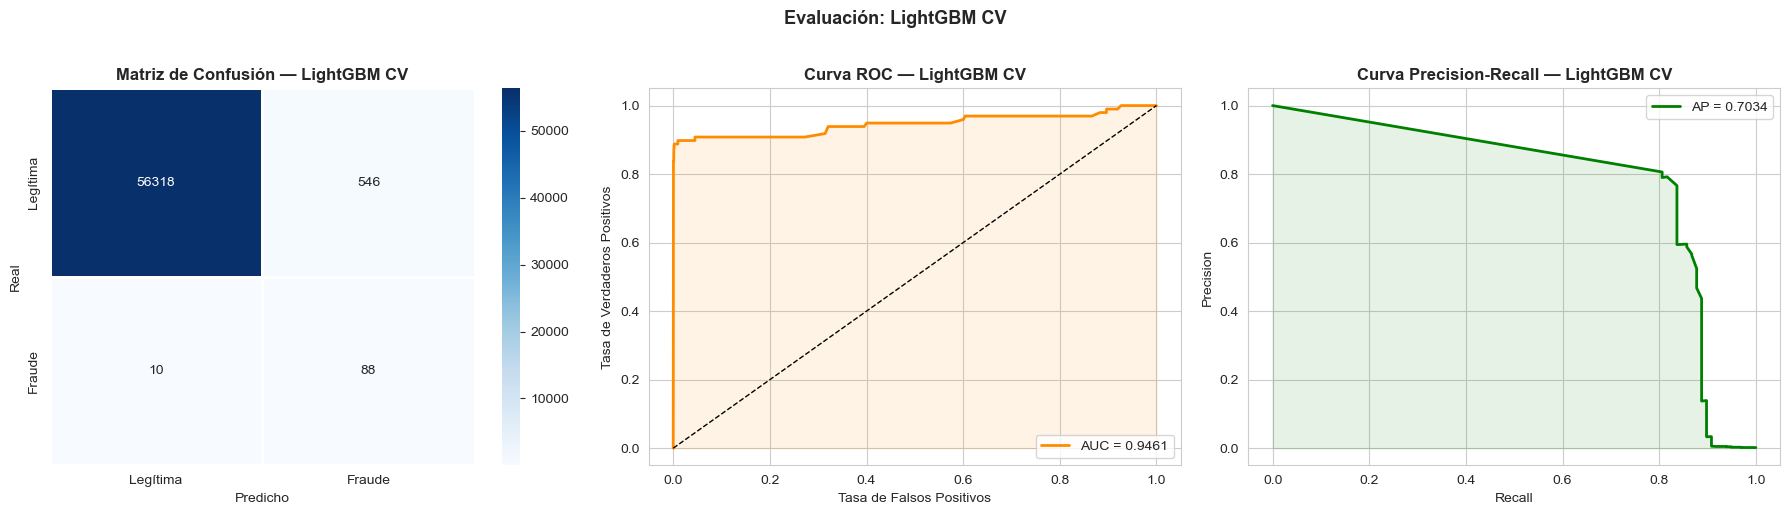

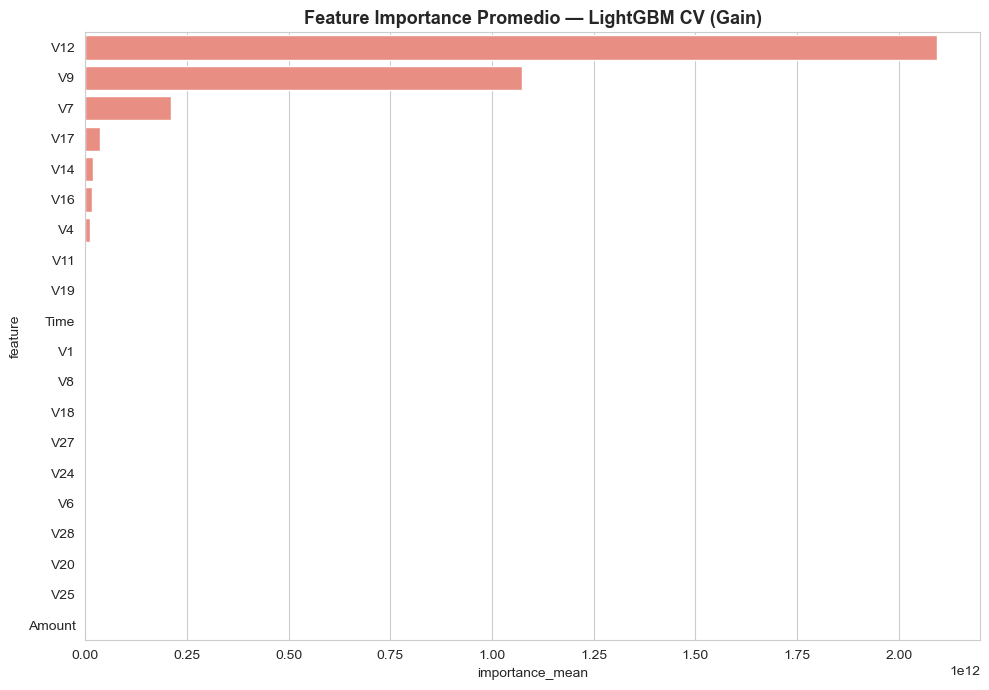

In [26]:
print(f'🔄 LightGBM con {NUMBER_KFOLDS}-Fold Stratified Cross-Validation...')

skf = StratifiedKFold(n_splits=NUMBER_KFOLDS, shuffle=True, random_state=RANDOM_STATE)

# Trabajamos con los datos SIN SMOTE para CV; el desbalance lo maneja scale_pos_weight
X_tv = pd.concat([X_train, X_valid]).reset_index(drop=True)
y_tv = pd.concat([y_train, y_valid]).reset_index(drop=True)

oof_preds  = np.zeros(len(X_tv))
test_preds = np.zeros(len(X_test))
cv_scores  = []

feat_imp_df = pd.DataFrame({'feature': PREDICTORS})

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tv, y_tv), 1):
    X_tr, X_vl = X_tv.iloc[tr_idx], X_tv.iloc[val_idx]
    y_tr, y_vl = y_tv.iloc[tr_idx], y_tv.iloc[val_idx]
    
    sp = int(y_tr.value_counts()[0] / y_tr.value_counts()[1])
    lgb_params['scale_pos_weight'] = sp
    
    d_tr = lgb.Dataset(X_tr, label=y_tr)
    d_vl = lgb.Dataset(X_vl, label=y_vl, reference=d_tr)
    
    m = lgb.train(
        lgb_params, d_tr,
        num_boost_round=MAX_ROUNDS,
        valid_sets=[d_vl],
        valid_names=['valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOP, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
    
    oof_preds[val_idx]  = m.predict(X_vl)
    test_preds         += m.predict(X_test) / NUMBER_KFOLDS
    feat_imp_df[f'fold_{fold}'] = m.feature_importance(importance_type='gain')
    
    fold_auc = roc_auc_score(y_vl, oof_preds[val_idx])
    cv_scores.append(fold_auc)
    print(f'  Fold {fold}/{NUMBER_KFOLDS} — AUC: {fold_auc:.5f}  (mejor ronda: {m.best_iteration})')

print(f'\n  AUC promedio CV : {np.mean(cv_scores):.5f}  ±  {np.std(cv_scores):.5f}')

# Evaluación en test
test_pred_labels = (test_preds > 0.5).astype(int)
evaluate_model('LightGBM CV', y_test, test_pred_labels, test_preds)

# Feature importance promedio
feat_imp_df['importance_mean'] = feat_imp_df[[f'fold_{i}' for i in range(1, NUMBER_KFOLDS+1)]].mean(axis=1)
feat_imp_df = feat_imp_df.sort_values('importance_mean', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x='importance_mean', y='feature', data=feat_imp_df, color='salmon')
plt.title('Feature Importance Promedio — LightGBM CV (Gain)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Comparación de Modelos <a id='comparacion'></a>

📊 Comparación de Modelos (Validation Set):


,AUC-ROC,Avg Precision,F1,Precision,Recall
LightGBM,0.9803,0.7278,0.4337,0.2913,0.8481
Random Forest,0.9747,0.7737,0.7006,0.6327,0.7848
XGBoost,0.9710,0.6997,0.2529,0.1494,0.8228
LightGBM CV,0.9461,0.7034,0.2404,0.1388,0.8980


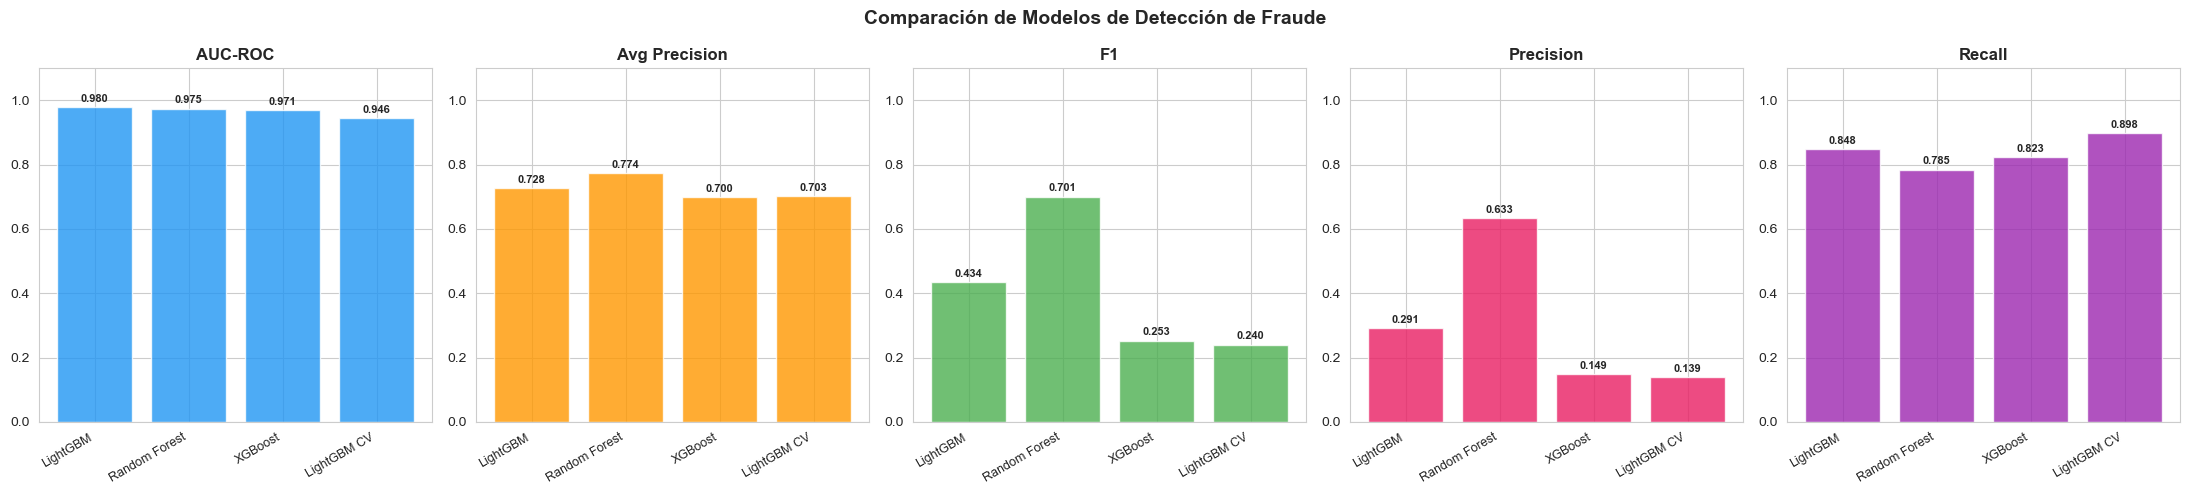


🏆 Mejor modelo por AUC-ROC: LightGBM (0.9803)


In [27]:
results_df = pd.DataFrame(results).T.sort_values('AUC-ROC', ascending=False)
results_df = results_df.round(4)

# Destacar mejor modelo
print('📊 Comparación de Modelos (Validation Set):')
display(results_df.style
    .background_gradient(cmap='Greens', subset=['AUC-ROC', 'Avg Precision', 'F1'])
    .highlight_max(subset=['AUC-ROC', 'F1', 'Recall'], color='#c6efce')
    .format('{:.4f}')
)

# Gráfico de barras comparativo
metrics_to_plot = ['AUC-ROC', 'Avg Precision', 'F1', 'Precision', 'Recall']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(22, 5))

palette = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']
for ax, metric, color in zip(axes, metrics_to_plot, palette):
    bars = ax.bar(results_df.index, results_df[metric], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Comparación de Modelos de Detección de Fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_model = results_df['AUC-ROC'].idxmax()
print(f'\n🏆 Mejor modelo por AUC-ROC: {best_model} ({results_df.loc[best_model, "AUC-ROC"]:.4f})')

---
## 8. Conclusiones <a id='conclusiones'></a>

### Resultados

Se entrenaron y compararon **5 modelos** de clasificación para la detección de fraude en tarjetas de crédito:

| Modelo | Fortaleza |
|---|---|
| Random Forest | Robusto, interpretable, maneja bien el ruido |
| AdaBoost | Buen baseline de boosting, fácil de ajustar |
| XGBoost | Alto rendimiento, eficiente en memoria |
| LightGBM | Muy rápido, excelente con datos grandes |
| LightGBM CV | Estimación más confiable vía K-Fold |

### Consideraciones para Producción

- **Umbral de decisión**: El umbral 0.5 es un punto de partida. En fraude, típicamente se baja para maximizar `Recall` (atrapar más fraudes, aunque con más falsos positivos).
- **Curva Precision-Recall**: Más informativa que ROC en datasets desbalanceados. Úsala para elegir el umbral según el costo del negocio.
- **Monitoreo en producción**: El patrón de fraude cambia con el tiempo (concept drift). Se recomienda re-entrenar periódicamente.
- **Costo asimétrico**: Un falso negativo (fraude no detectado) suele costar mucho más que un falso positivo (transacción legítima bloqueada).

### Próximos Pasos Sugeridos

1. **Optimización de hiperparámetros** con Optuna o GridSearchCV
2. **Ensemble/Stacking** combinando los mejores modelos
3. **Ingeniería de features** adicional (frecuencia de transacciones por hora, historial del cliente)
4. **Análisis de errores** — revisar qué tipos de fraude se están perdiendo
5. **Explicabilidad** con SHAP values para auditorías

In [28]:
print('✅ Notebook completado exitosamente.')
print(f'   Modelos entrenados: {list(results.keys())}')
print(f'   Mejor AUC-ROC: {results_df["AUC-ROC"].max():.4f} ({best_model})')

✅ Notebook completado exitosamente.
   Modelos entrenados: ['Random Forest', 'XGBoost', 'LightGBM', 'LightGBM CV']
   Mejor AUC-ROC: 0.9803 (LightGBM)
